<h1>Gaia Star Cluster Hertzsprung Russel Diagrams (HRD)</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [Measuring the Age of a Star Cluster](https://www.e-education.psu.edu/astro801/content/l7_p6.html#:~:text=The%20HR%20diagram%20for%20stage,%2D13%20billion%20years%20old)

**In the examples below we will query open clusters in the Milky way and plot it in a Hertzsprung-Russel Diagram (HRD). We will also attempt to identify Zero-order Main Sequence (ZAMS) entry points and Main Sequence Cutoff for these star clusters**

*adapted for the Python for Astronomy Course by Chandru Narayan Nov 1, 2022 using the material develped by Dr. Priya Hasan*

# Steps to create Hertzsprung-Russel Diagram

- Step 1: Installs the required libraries for astronomy data analysis, querying, and plotting.
- Step 2: Imports the necessary modules from the installed libraries.
- Step 3: Queries the Gaia archive for data within a specified radius around a given cluster.
- Step 4: Calculates absolute magnitudes and colors from the Gaia data.
- Step 5: Generates an HR diagram, plotting absolute magnitude against color.

## Step 1: Install necessary libraries as necessary

In [1]:
# pip install astropy astroquery matplotlib

## Step 2: Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia
import astropy.coordinates as coord
import pandas as pd

## Step 3: Query Gaia data

In [3]:
# Parameters for API Query & HRD (20 minutes radius around Cluster center) - Change for each query!
target = "M67" # target to query
object_radius = 1 * u.deg # in deg
coordinate = coord.SkyCoord.from_name(target)
print(coordinate)


<SkyCoord (ICRS): (ra, dec) in deg
    (132.846, 11.814)>


In [4]:
# Define cluster coordinates and radius for Cone search
radius = object_radius
ra = coordinate.ra
dec = coordinate.dec

# Query Gaia
query = f"""
    SELECT source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE bp_rp > -0.75 AND bp_rp < 4 AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
        )
""" 
job = Gaia.launch_job_async(query)
gaia_data = job.get_results()
#print(gaia_data)

INFO: Query finished. [astroquery.utils.tap.core]


## Step 4: Cleanup Gaia Query Results data

In [5]:
# Create a DataFrame:
allstars = gaia_data.to_pandas()
print(allstars)
# filter allstars (temp1)
temp1 = allstars.dropna()  # Drop NaN - "not a number"
print(temp1)
# filter parallax > 0 (allstars_filtered) by creating a mask
mask = (allstars.parallax > 1)
allstars_filtered = allstars[mask]
#print(allstars_filtered)
allstars = allstars_filtered.dropna()
#print(allstars)

                source_id          ra        dec  parallax  phot_g_mean_mag  \
0      604625910880696960  133.409667  10.983092       NaN        21.822149   
1      604626082680673920  133.445963  11.008143       NaN        21.120874   
2      604626117039126784  133.399230  10.980871 -0.501336        19.757692   
3      604626121334201984  133.391235  10.987632  0.906051        15.138968   
4      604626151398869248  133.409033  11.001376  0.298192        18.443552   
...                   ...         ...        ...       ...              ...   
19976  601999933516072448  131.905005  12.200895 -1.208950        20.228256   
19977  602000070954870144  131.929875  12.225758 -0.311625        19.691404   
19978  602000070955261184  131.919748  12.223423 -2.436351        20.423265   
19979  602000075250173056  131.924439  12.233467  0.461602        13.469939   
19980  602000075251139456  131.920202  12.221731       NaN        20.412905   

          bp_rp  
0      2.915867  
1      1.392183

## Step 4: Calculate absolute magnitude and add to DataFrame

### Review Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
##### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
#### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
##### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [6]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

distance_modulus = -5 * np.log10(allstars['parallax']) + 10
abs_mag = allstars['phot_g_mean_mag'] - distance_modulus
bp_rp = allstars['bp_rp']

## Step 5: Plot HR diagram

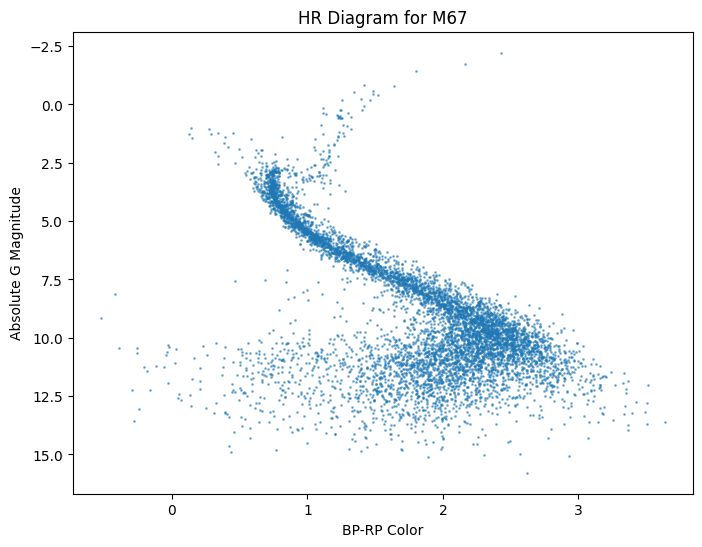

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {target}")
plt.show()

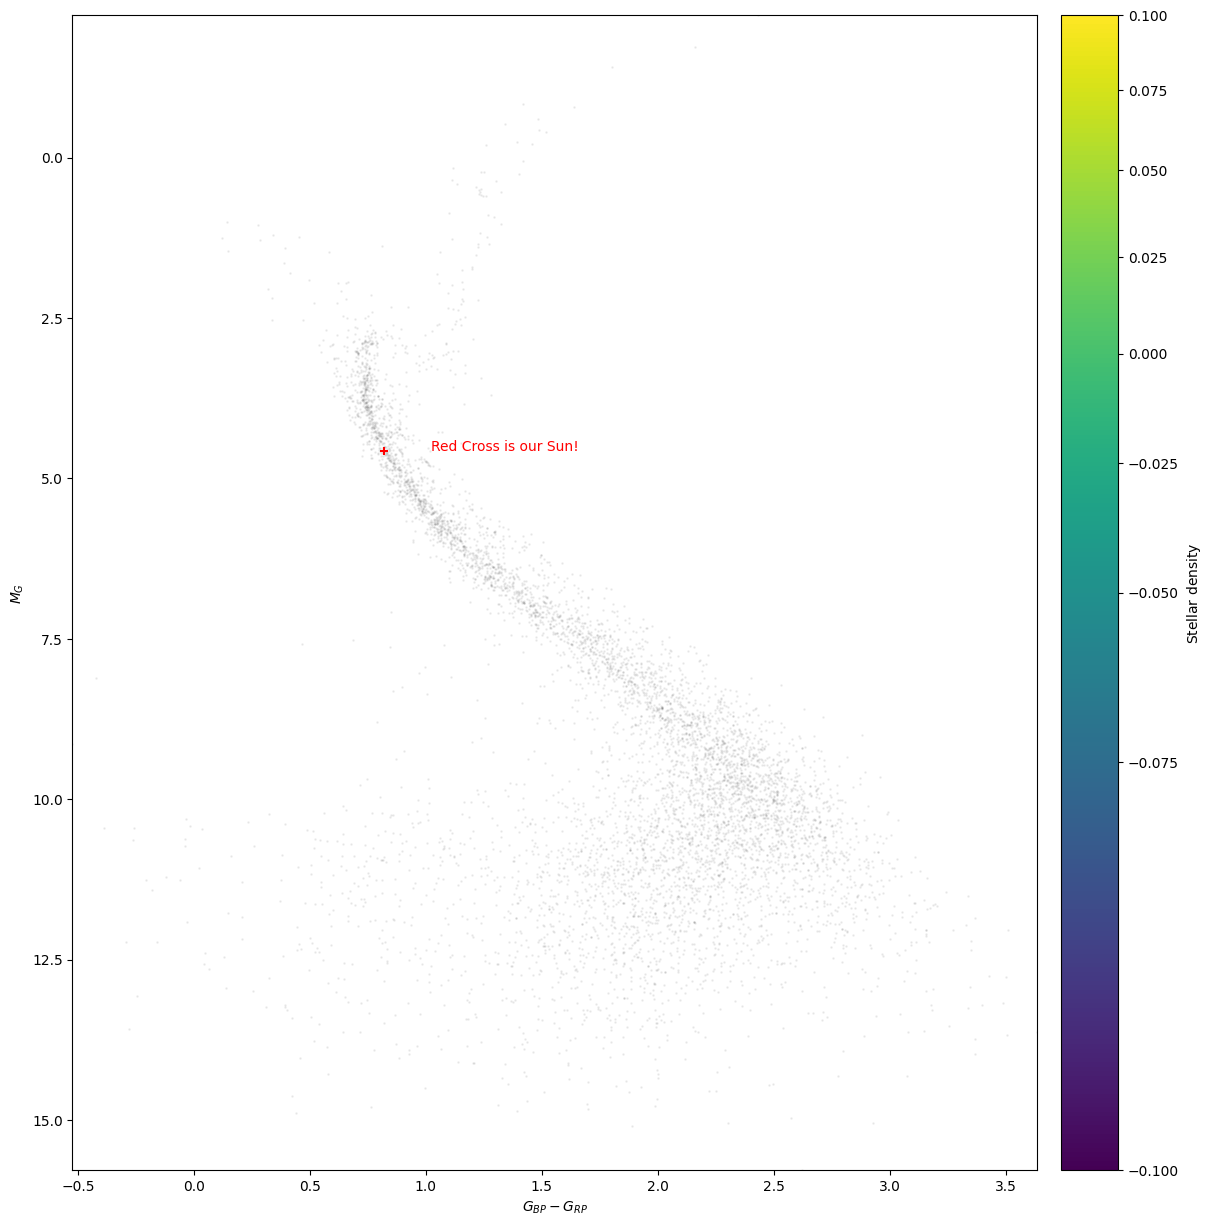

In [8]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * math.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

# only show 2D-histogram for bins with more than 10 stars in them
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
#h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
h = ax.hist2d(bp_rp,abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp,abs_mag, alpha=0.05, s=1, color='k', zorder=0)

plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"m67.png", dpi=140)
plt.show()

## Step 3: Query Gaia data

In [9]:
# Parameters for API Query & HRD (20 minutes radius around Cluster center) - Change for each query!
target = "M45" # target to query
object_radius = 1 * u.deg # in deg
coordinate = coord.SkyCoord.from_name(target)
print(coordinate)


<SkyCoord (ICRS): (ra, dec) in deg
    (56.601, 24.114)>


In [10]:
# Define cluster coordinates and radius for Cone search
radius = object_radius
ra = coordinate.ra
dec = coordinate.dec

# Query Gaia
query = f"""
    SELECT source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE bp_rp > -0.75 AND bp_rp < 4 AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
        )
""" 
job = Gaia.launch_job_async(query)
gaia_data = job.get_results()
#print(gaia_data)

INFO: Query finished. [astroquery.utils.tap.core]


## Step 4: Cleanup Gaia Query Results data

In [11]:
# Create a DataFrame:
allstars = gaia_data.to_pandas()
print(allstars)
# filter allstars (temp1)
temp1 = allstars.dropna()  # Drop NaN - "not a number"
print(temp1)
# filter parallax > 0 (allstars_filtered) by creating a mask
mask = (allstars.parallax > 0)
allstars_filtered = allstars[mask]
#print(allstars_filtered)
allstars = allstars_filtered.dropna()
#print(allstars)

               source_id         ra        dec  parallax  phot_g_mean_mag  \
0      68163707968001280  55.522382  23.949931 -0.049308        18.436476   
1      68163845406964736  55.528901  23.966757  1.723788        19.867399   
2      68163845406966656  55.529875  23.970182  0.381253        20.340611   
3      68163849702291200  55.541408  23.971898  1.833434        19.825632   
4      68163879766705280  55.521874  23.969873  0.453870        19.109646   
...                  ...        ...        ...       ...              ...   
26557  69846235637202304  56.547416  25.112504  1.401909        20.640131   
26558  69846239933720320  56.547782  25.110088       NaN        21.612818   
26559  69846480451892096  56.468896  25.082041       NaN        21.128405   
26560  69846514810319104  56.471198  25.095850       NaN        20.781590   
26561  69846549171304960  56.451914  25.095828       NaN        20.979465   

          bp_rp  
0      1.166471  
1      2.370613  
2      0.998310  
3  

## Step 4: Calculate absolute magnitude and add to DataFrame

### Review Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
##### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
#### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
##### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [12]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

distance_modulus = -5 * np.log10(allstars['parallax']) + 10
abs_mag = allstars['phot_g_mean_mag'] - distance_modulus
bp_rp = allstars['bp_rp']
#print(allstars)

## Step 5: Plot HR diagram

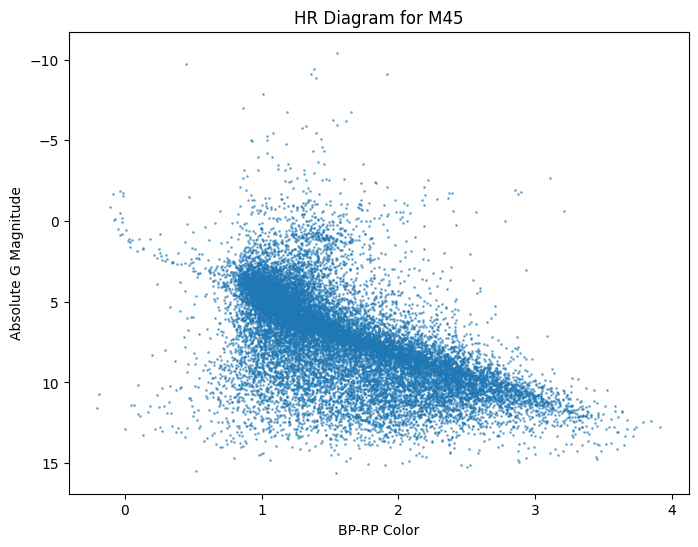

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {target}")
plt.show()

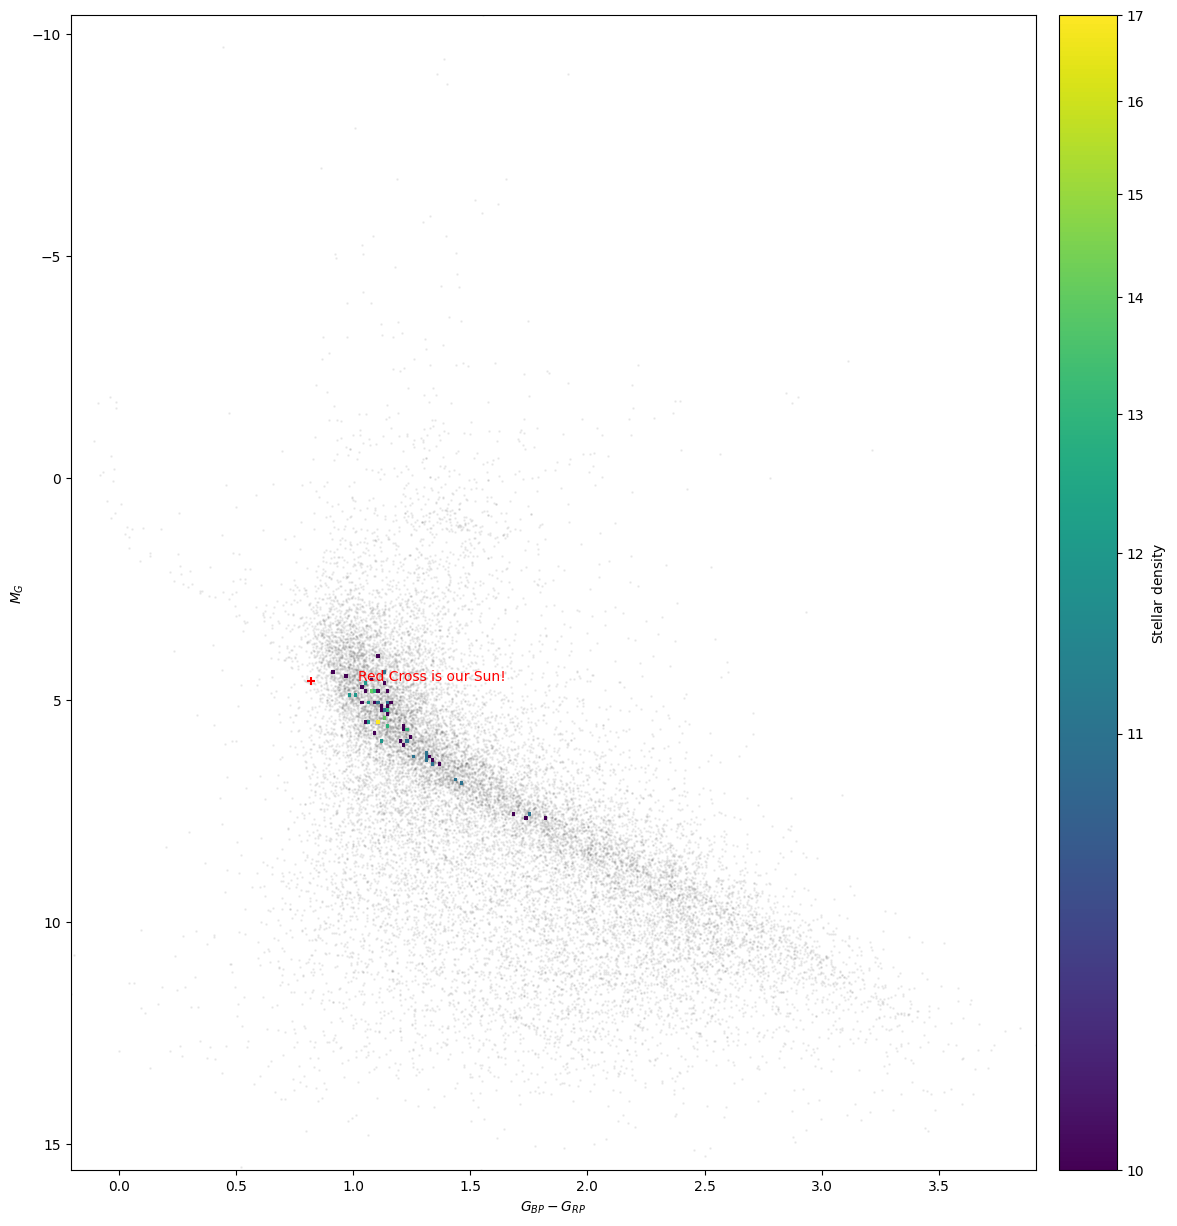

In [14]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * math.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

# only show 2D-histogram for bins with more than 10 stars in them
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
#h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
h = ax.hist2d(bp_rp,abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp,abs_mag, alpha=0.05, s=1, color='k', zorder=0)

plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"m67.png", dpi=140)
plt.show()

## Step 3: Query Gaia data

In [15]:
# Parameters for API Query & HRD (20 minutes radius around Cluster center) - Change for each query!
target = "NGC884" # target to query
object_radius = 1 * u.deg # in deg
coordinate = coord.SkyCoord.from_name(target)
print(coordinate)


<SkyCoord (ICRS): (ra, dec) in deg
    (35.584, 57.149)>


In [16]:
# Define cluster coordinates and radius for Cone search
radius = object_radius
ra = coordinate.ra
dec = coordinate.dec

# Query Gaia
query = f"""
    SELECT source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE bp_rp > -0.75 AND bp_rp < 4 AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
        )
""" 
job = Gaia.launch_job_async(query)
gaia_data = job.get_results()
#print(gaia_data)

INFO: Query finished. [astroquery.utils.tap.core]


## Step 4: Cleanup Gaia Query Results data

In [17]:
# Create a DataFrame:
allstars = gaia_data.to_pandas()
print(allstars)
# filter allstars (temp1)
temp1 = allstars.dropna()  # Drop NaN - "not a number"
print(temp1)
# filter parallax > 0 (allstars_filtered) by creating a mask
mask = (allstars.parallax > 0)
allstars_filtered = allstars[mask]
#print(allstars_filtered)
allstars = allstars_filtered.dropna()
#print(allstars)

                 source_id         ra        dec  parallax  phot_g_mean_mag  \
0       457572007396058624  36.909113  56.534927  0.857648        20.045391   
1       457572007397232896  36.908716  56.535432 -1.578685        20.136045   
2       457572007397701248  36.904571  56.538107 -0.539797        20.756771   
3       457572007404764672  36.921524  56.541725  0.449621        15.588798   
4       457572007407905920  36.900599  56.542264  0.182271        17.200958   
...                    ...        ...        ...       ...              ...   
196380  458572489964576896  34.308109  57.390210  0.288182        19.639360   
196381  458572489964601600  34.298861  57.394825  0.024788        18.364016   
196382  458572489964602368  34.292928  57.395191  0.107387        18.940731   
196383  458572494261010432  34.287588  57.392472 -0.412344        19.950562   
196384  458572494262139904  34.296198  57.388870       NaN        20.820440   

           bp_rp  
0       1.939804  
1       1.777

## Step 4: Calculate absolute magnitude and add to DataFrame

### Review Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
##### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
#### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
##### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [18]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

distance_modulus = -5 * np.log10(allstars['parallax']) + 10
abs_mag = allstars['phot_g_mean_mag'] - distance_modulus
bp_rp = allstars['bp_rp']
#print(allstars)

## Step 5: Plot HR diagram

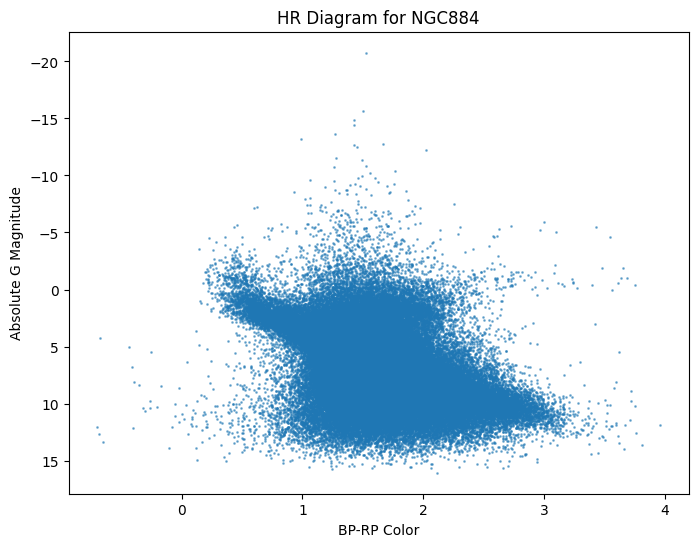

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {target}")
plt.show()

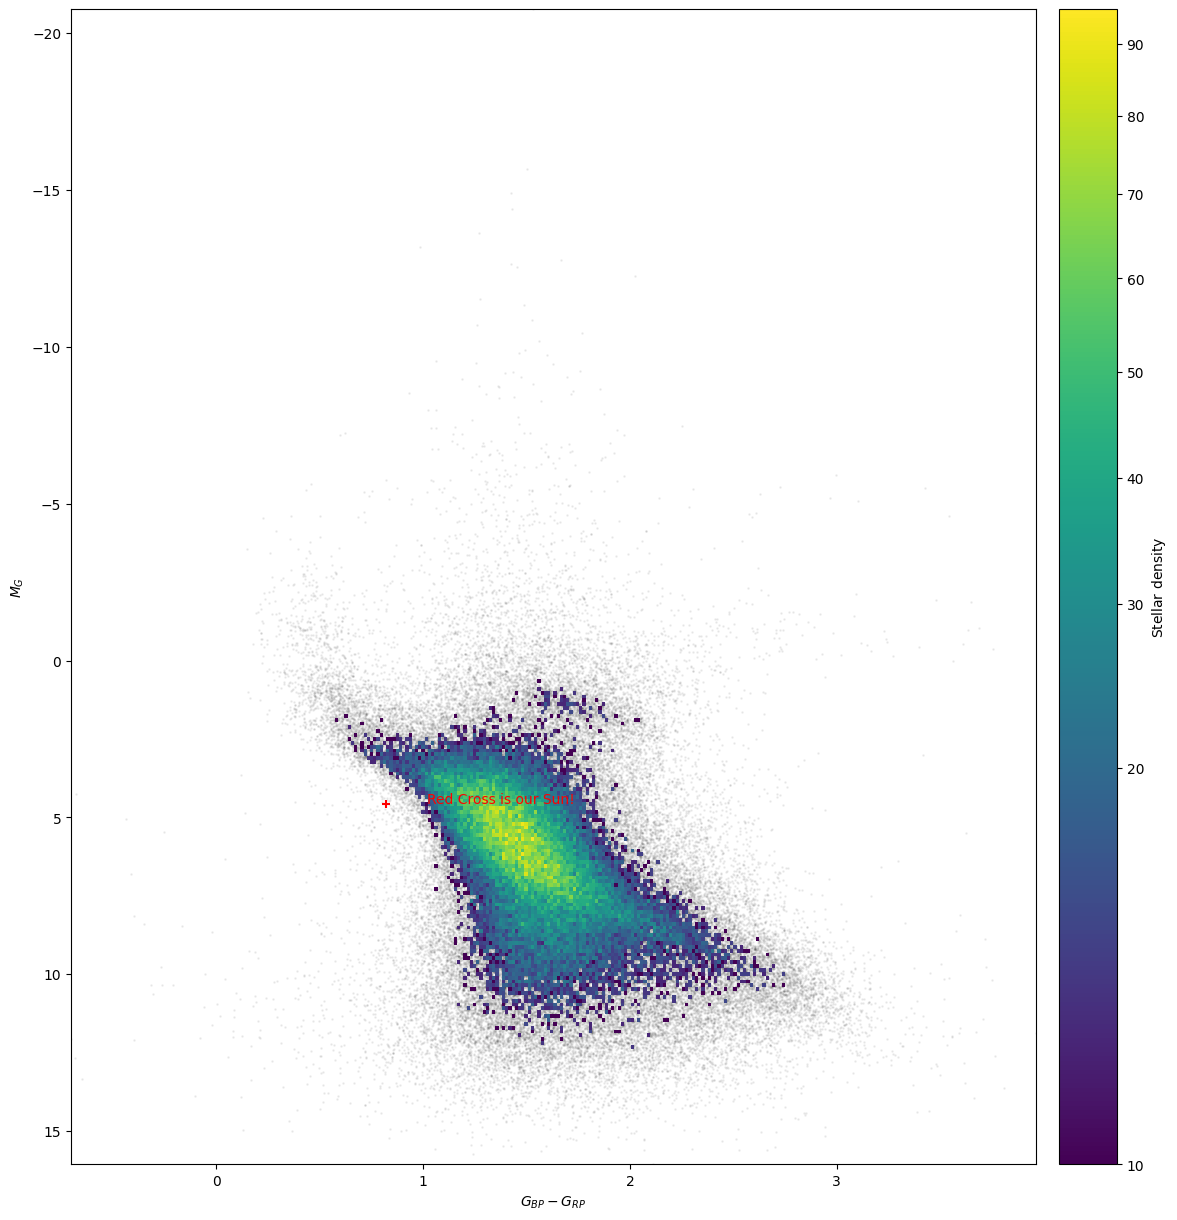

In [20]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * math.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

# only show 2D-histogram for bins with more than 10 stars in them
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
#h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
h = ax.hist2d(bp_rp,abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp,abs_mag, alpha=0.05, s=1, color='k', zorder=0)

plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"m67.png", dpi=140)
plt.show()